In [ ]:
import pandas as pd

df_results = pd.read_csv('results.csv')
df_results['batch_size'] = 0
df_results['distinction'] = 'original'
df_results_batch_32 = pd.read_csv('results_batch_32.csv')
df_results_batch_32['batch_size'] = 32
df_results_batch_32['distinction'] = 'batch_32'

df_results_batch_64 = pd.read_csv('results_batch_64.csv')
df_results_batch_64['batch_size'] = 64
df_results_batch_64['distinction'] = 'batch_64'


concatenated_df = pd.concat([df_results, df_results_batch_32, df_results_batch_64], ignore_index=True)

print(concatenated_df.head())
print(concatenated_df['batch_size'].unique())

   Unnamed: 0                                         Experiment  \
0           0  Baseline (No Speculative Decoding) - Biochem (...   
1           1  Baseline (No Speculative Decoding) - Biochem (...   
2           2  Baseline (No Speculative Decoding) - Biochem (...   
3           3  Baseline (No Speculative Decoding) - Biochem (...   
4           4  Baseline (No Speculative Decoding) - Biochem (...   

   Prompt Index                                             Prompt  \
0             0  Explain the protocols for the serial dilution,...   
1             1  Develop a comprehensive laboratory exercise on...   
2             2  Compose instructions for the preparation and u...   
3             3  Generate an in-depth guide for isolating and c...   
4             4  Explain the necessary precautions, materials, ...   

                   Main Model     Draft Model  Num Speculative Tokens  \
0  Qwen/Qwen2.5-1.5B-Instruct  N/A (Baseline)                       0   
1  Qwen/Qwen2.5-1.5B-Ins

In [ ]:
df_global = concatenated_df

## Analysis code


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def analysis(model_filter = 'Int8', batch_size=32):
    final_results_df = df_global[df_global["batch_size"] == batch_size]
    int4_filtered_results = final_results_df[
        final_results_df['Draft Model'].str.contains(model_filter) |
        (final_results_df['Draft Model'] == 'N/A (Baseline)')
    ].copy()

    int4_plot_df = int4_filtered_results.groupby(
        ['Experiment', 'Draft Model', 'Num Speculative Tokens', 'Category']
    ).agg({
        'Latency (ms/token)': 'mean',
        'Acceptance rate': 'mean',
        'Avg Acceptance Length': 'mean',
        'VRAM smi (GB)': 'mean',
        'Draft Gen Speed (tokens/s)': 'mean'
    }).reset_index()

    int4_plot_df['Num Speculative Tokens'] = pd.to_numeric(int4_plot_df['Num Speculative Tokens'])

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=int4_plot_df,
        x='Category',
        y='Latency (ms/token)',
        hue='Num Speculative Tokens',
        palette='viridis'
    )
    plt.title(f'Average Latency per Token across Categories by Num Speculative Tokens ({model_filter}) - Batch {batch_size}')
    plt.xlabel('Category')
    plt.ylabel('Average Latency (ms/token)')
    plt.grid(axis='y')
    plt.legend(title='Num Speculative Tokens', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(8, 5))

    int4_acceptance_plot_df = int4_plot_df[int4_plot_df['Num Speculative Tokens'] > 0]
    sns.barplot(
        data=int4_acceptance_plot_df,
        x='Category',
        y='Acceptance rate',
        hue='Num Speculative Tokens',
        palette='viridis'
    )
    plt.title(f'Average Acceptance Rate across Categories by Num Speculative Tokens ({model_filter}) - Batch {batch_size}')
    plt.xlabel('Category')
    plt.ylabel('Average Acceptance Rate (%)')
    plt.grid(axis='y')
    plt.legend(title='Num Speculative Tokens', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(8, 5))
    int4_mean_acceptance_length_plot_df = int4_plot_df[int4_plot_df['Num Speculative Tokens'] > 0]
    sns.barplot(
        data=int4_mean_acceptance_length_plot_df,
        x='Category',
        y='Avg Acceptance Length',
        hue='Num Speculative Tokens',
        palette='viridis'
    )
    plt.title(f'Mean Acceptance Length across Categories by Num Speculative Tokens ({model_filter}) - Batch {batch_size}')
    plt.xlabel('Category')
    plt.ylabel('Mean Acceptance Length')
    plt.grid(axis='y')
    plt.legend(title='Num Speculative Tokens', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(8, 5))
    int4_draft_gen_speed_plot_df = int4_plot_df[int4_plot_df['Num Speculative Tokens'] > 0]
    sns.barplot(
        data=int4_draft_gen_speed_plot_df,
        x='Category',
        y='Draft Gen Speed (tokens/s)',
        hue='Num Speculative Tokens',
        palette='viridis'
    )
    plt.title(f'Average Draft Generation Speed across Categories by Num Speculative Tokens ({model_filter}) - Batch {batch_size}')
    plt.xlabel('Category')
    plt.ylabel('Average Draft Generation Speed (tokens/s)')
    plt.grid(axis='y')
    plt.legend(title='Num Speculative Tokens', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


    baseline_latencies = int4_plot_df[int4_plot_df['Num Speculative Tokens'] == 0].set_index('Category')['Latency (ms/token)']

    speed_up_df = int4_plot_df[int4_plot_df['Num Speculative Tokens'] > 0].copy()
    speed_up_df['Speed-up Coefficient'] = speed_up_df.apply(lambda row: baseline_latencies[row['Category']] / row['Latency (ms/token)'], axis=1)

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=speed_up_df,
        x='Category',
        y='Speed-up Coefficient',
        hue='Num Speculative Tokens',
        palette='viridis'
    )
    plt.title(f'Average Speed-up Coefficient across Categories by Num Speculative Tokens ({model_filter}) - Batch {batch_size}')
    plt.xlabel('Category')
    plt.ylabel('Speed-up Coefficient')
    plt.grid(axis='y')
    plt.legend(title='Num Speculative Tokens', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Batch size 32

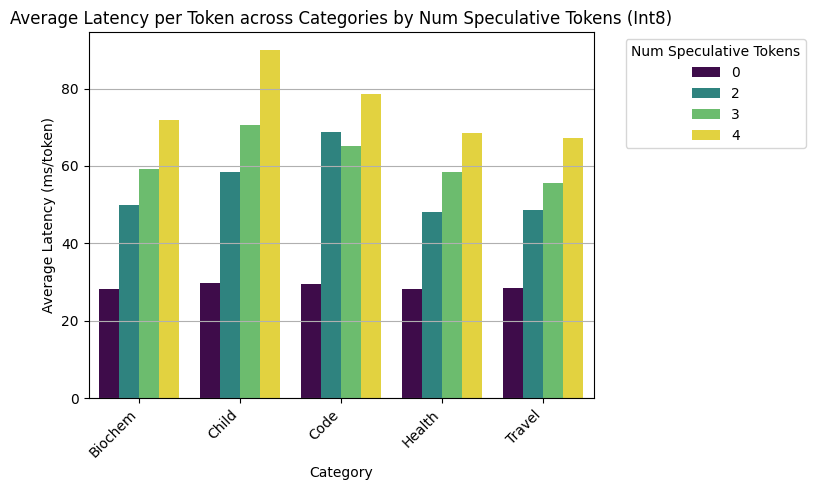

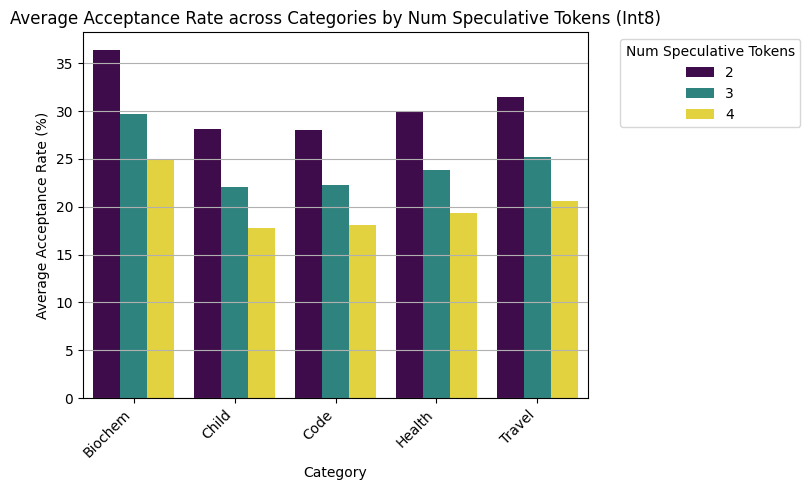

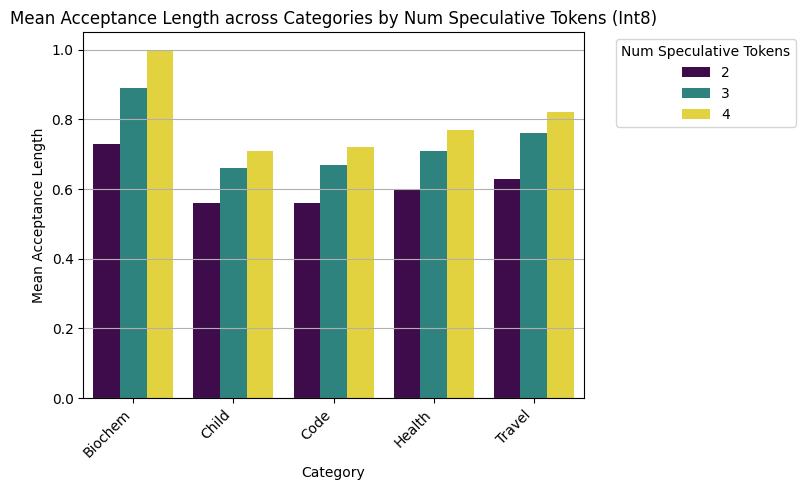

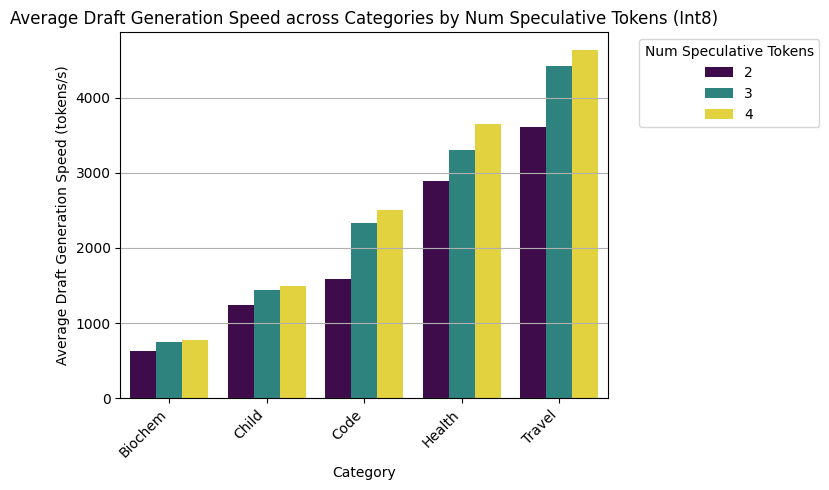

In [ ]:
analysis(model_filter='Int8', batch_size=32)

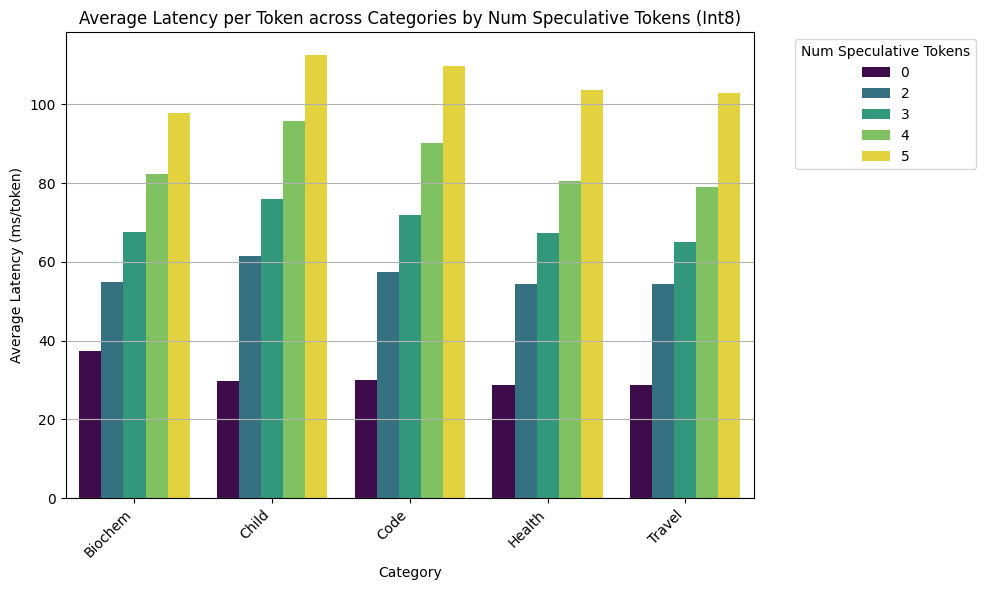

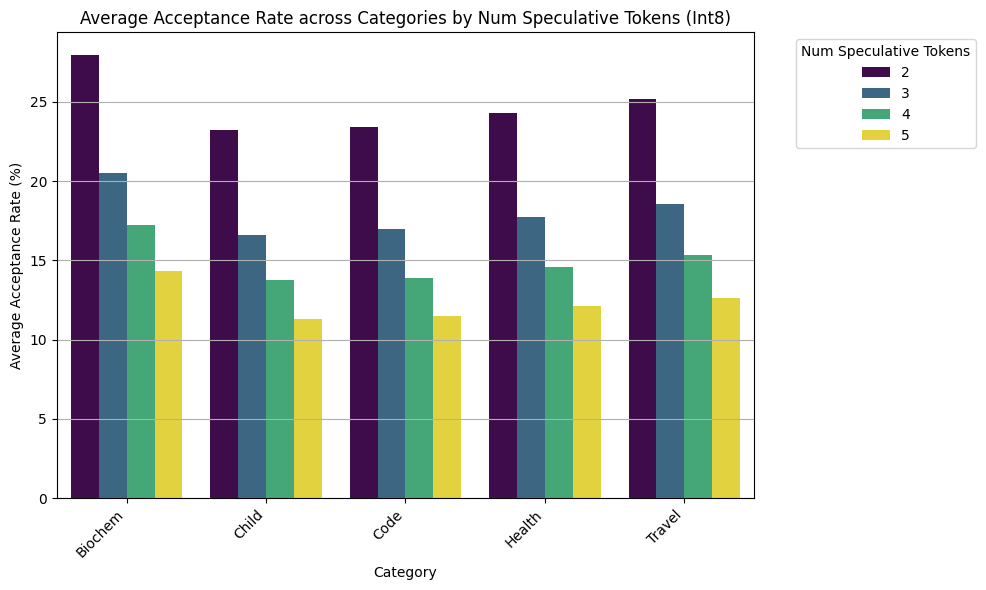

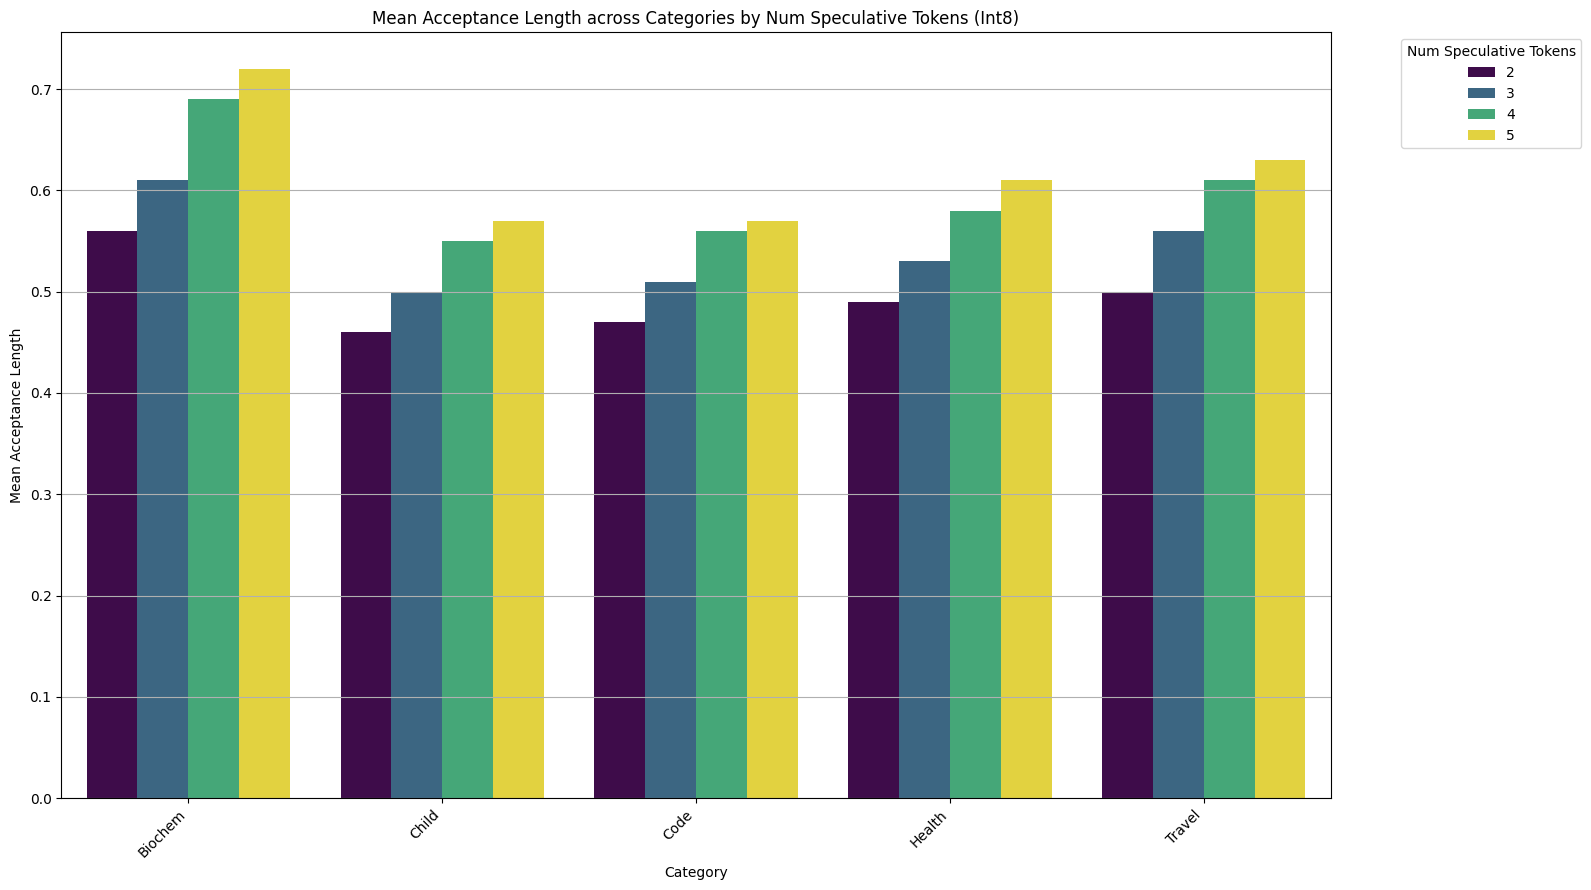

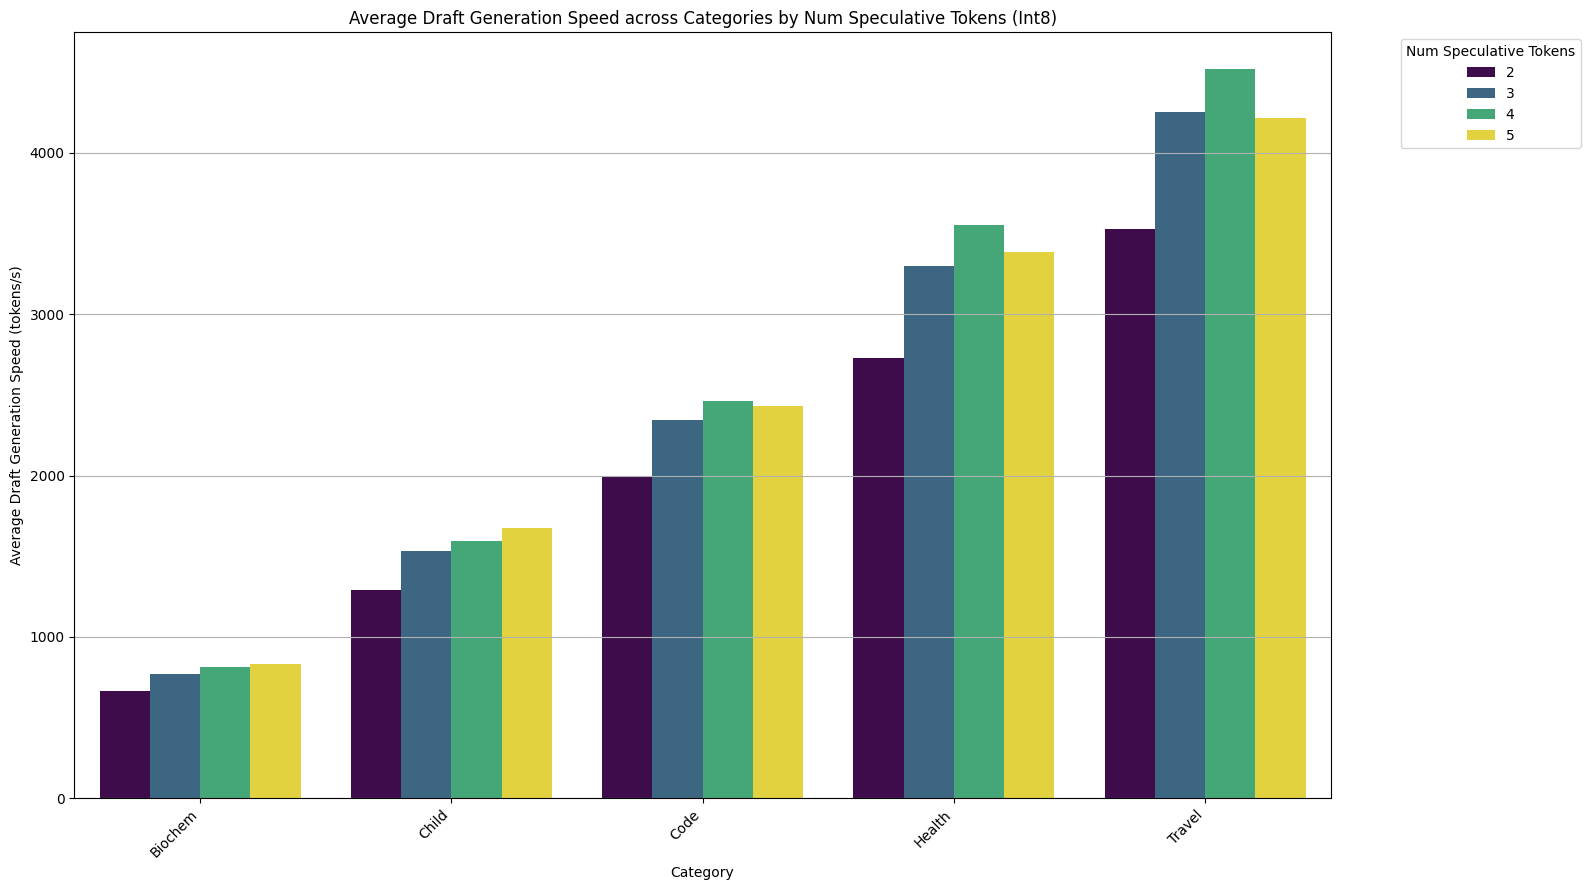

In [ ]:
analysis(model_filter='Int4', batch_size=32)

## Неограниченный batch size

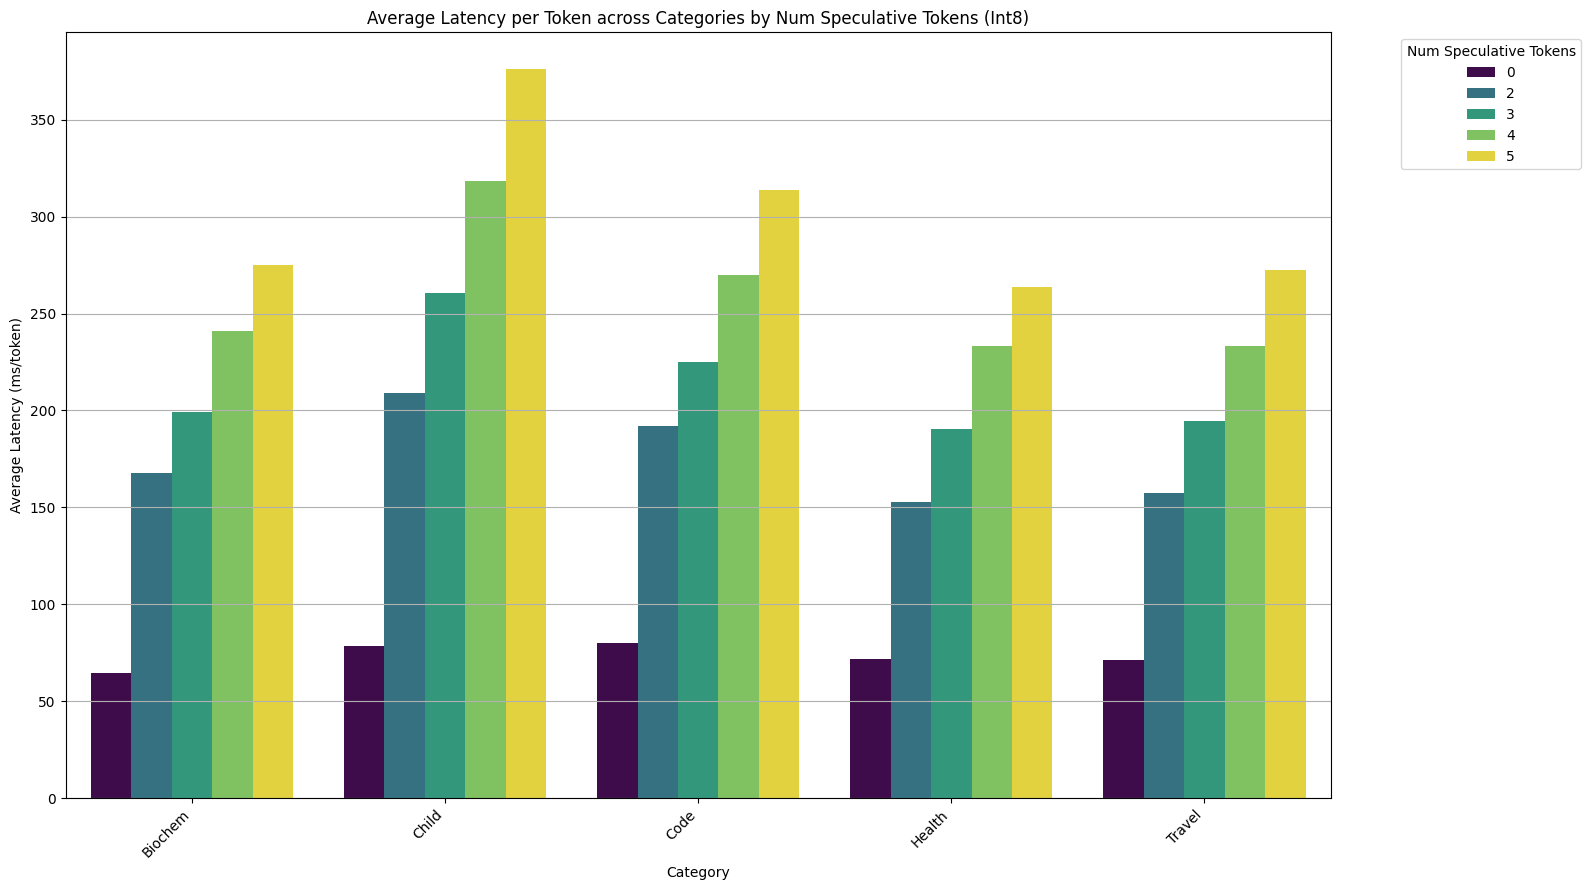

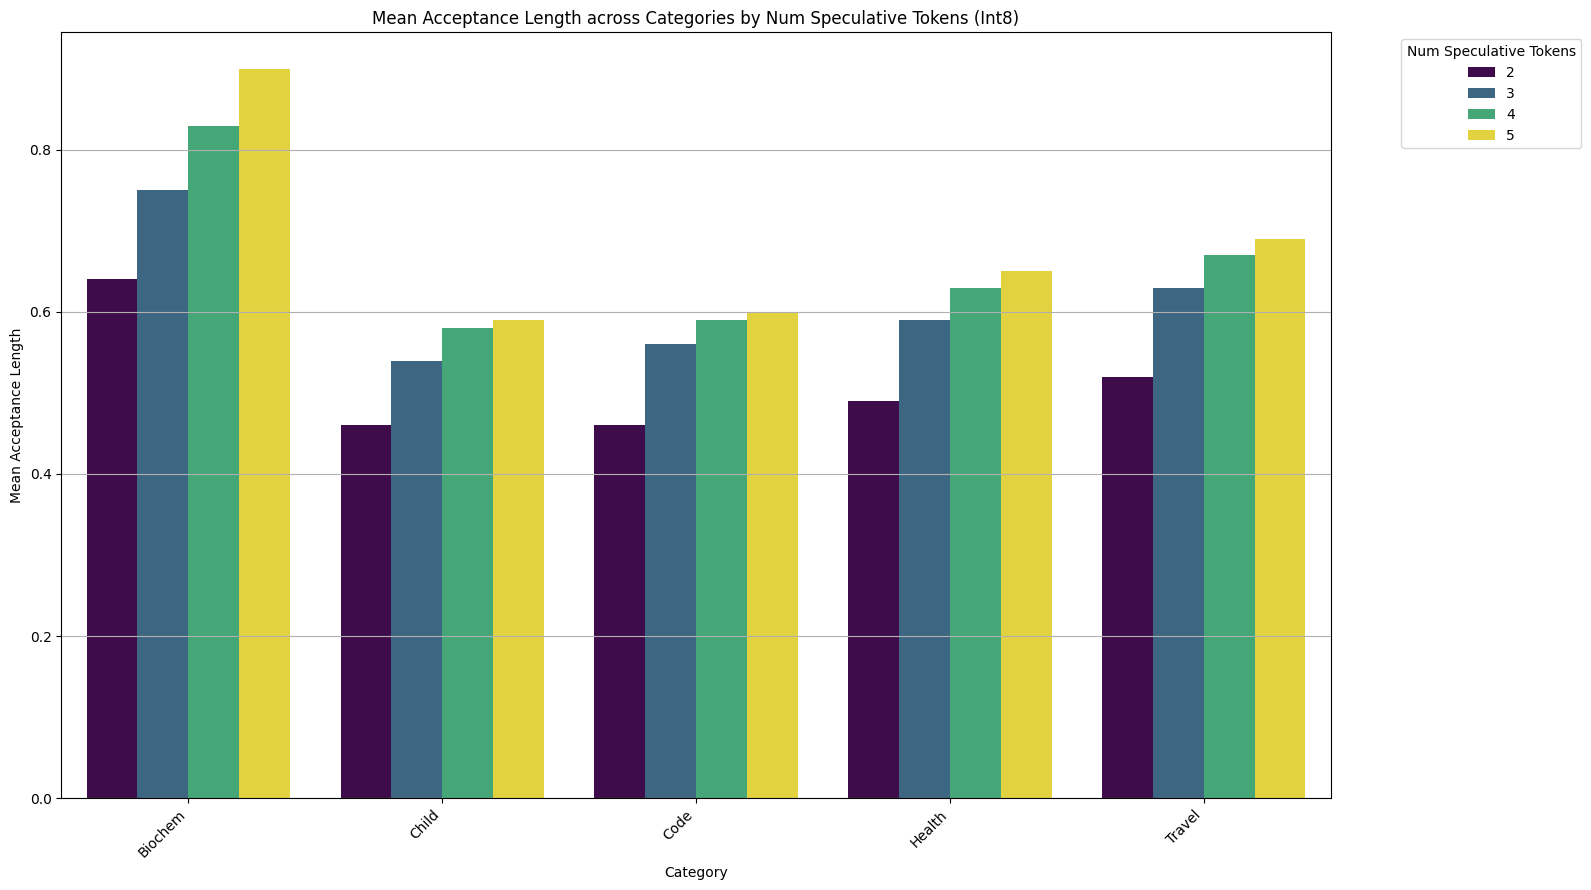

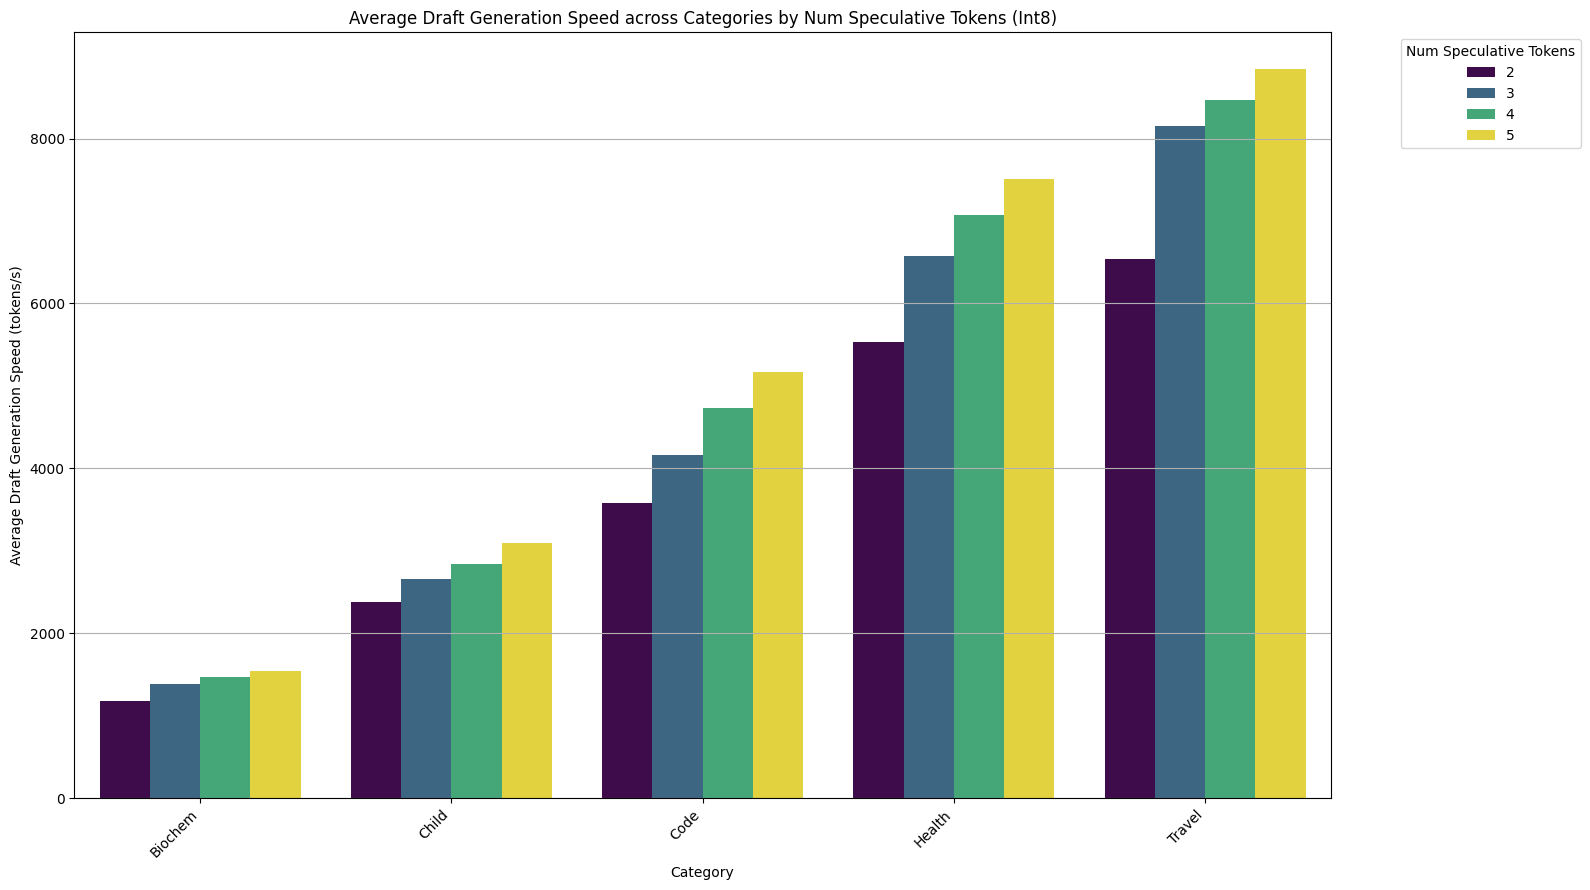

In [ ]:
analysis(model_filter = 'Int8', batch_size=0)

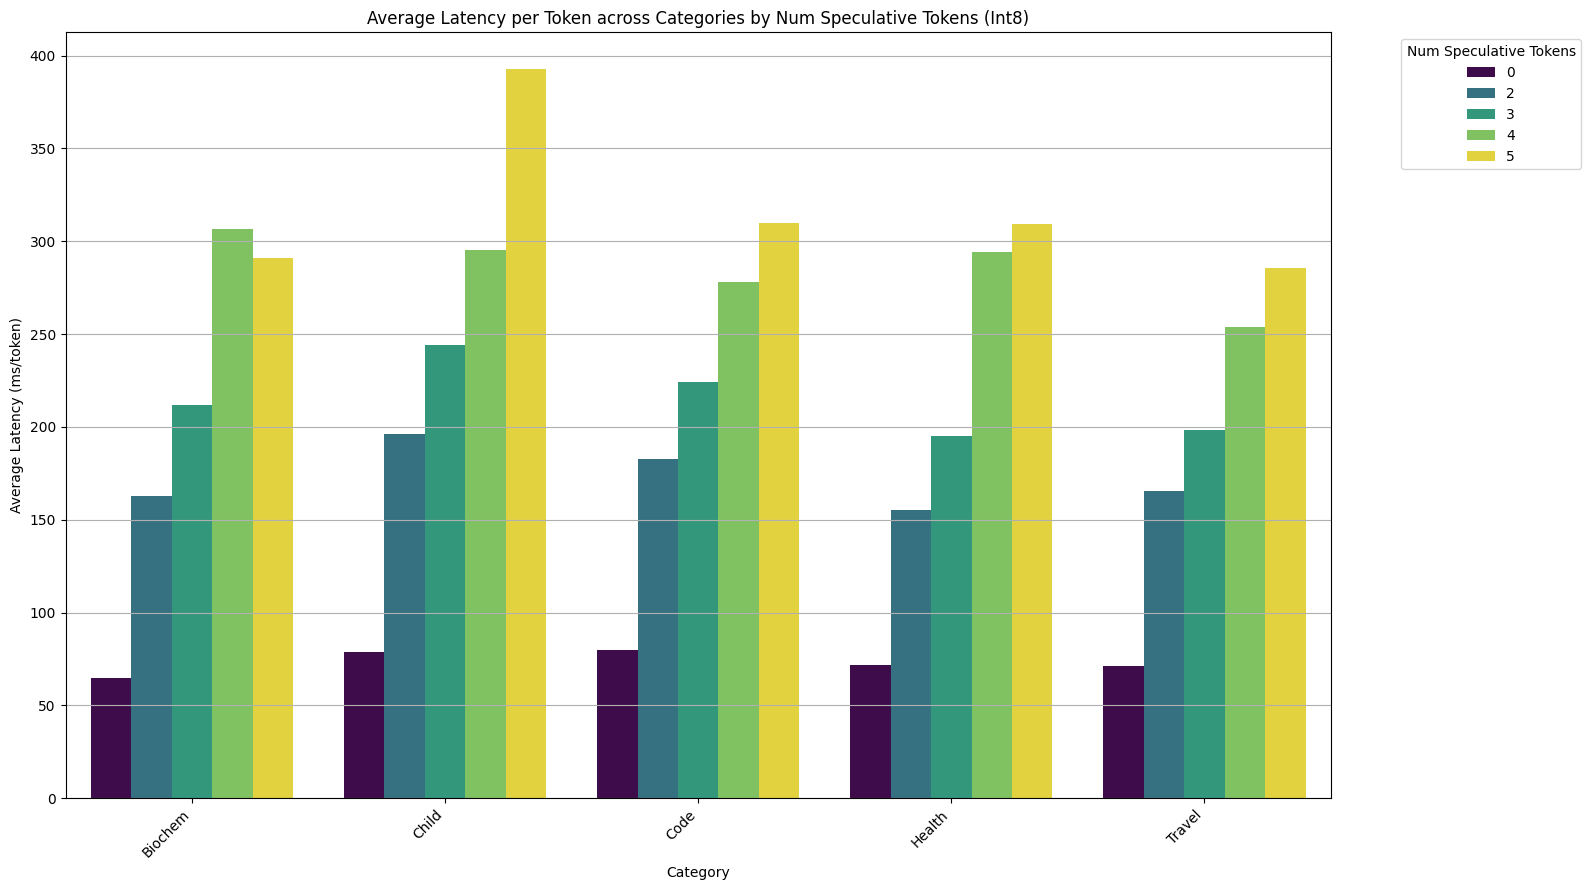

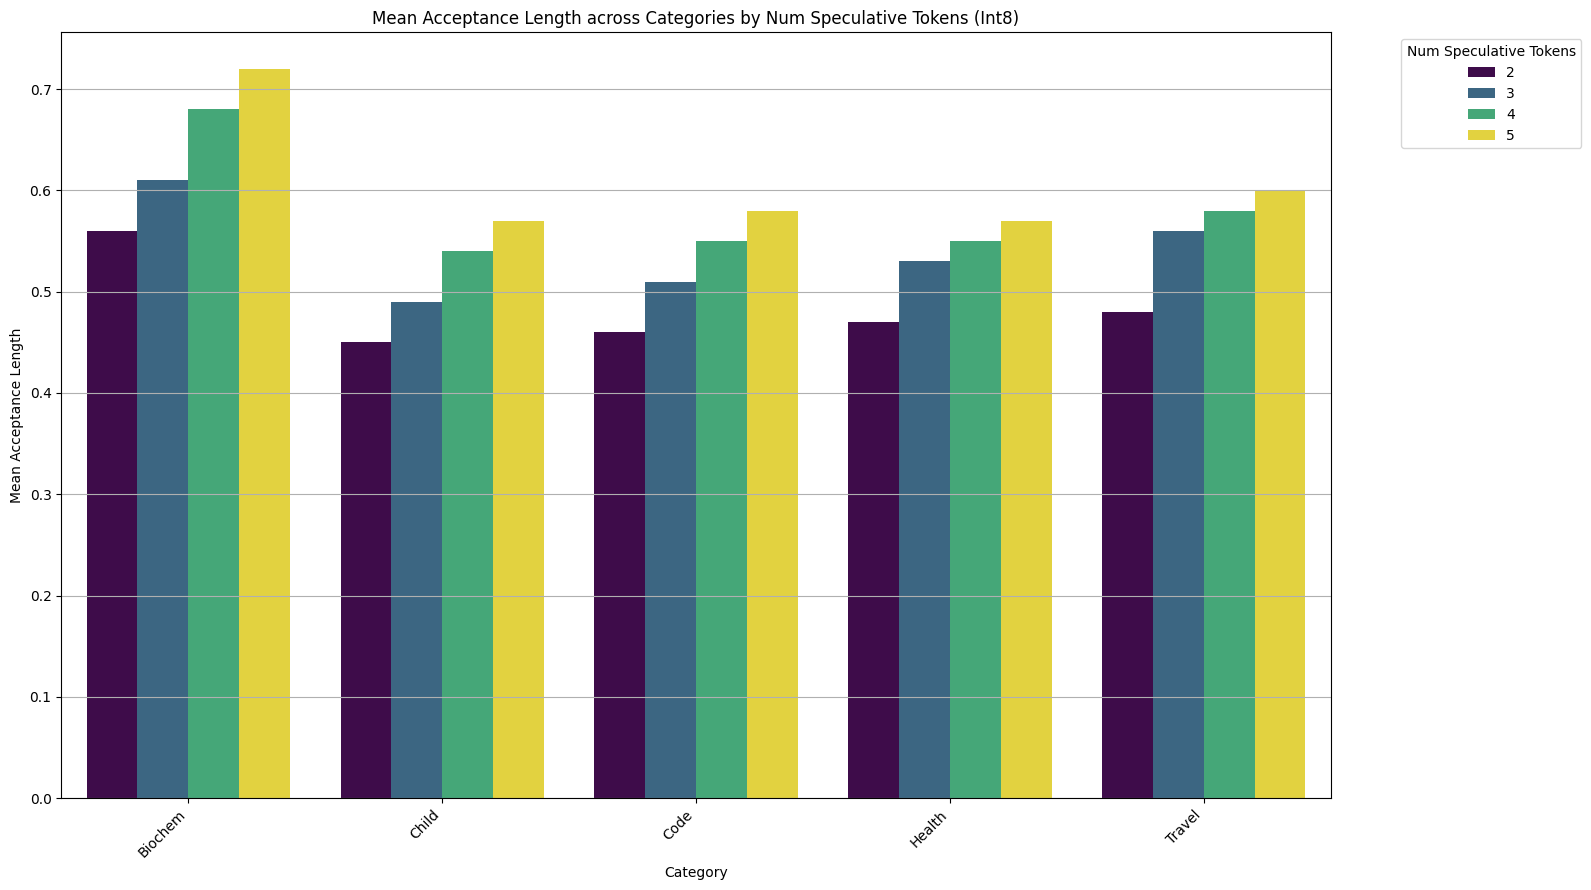

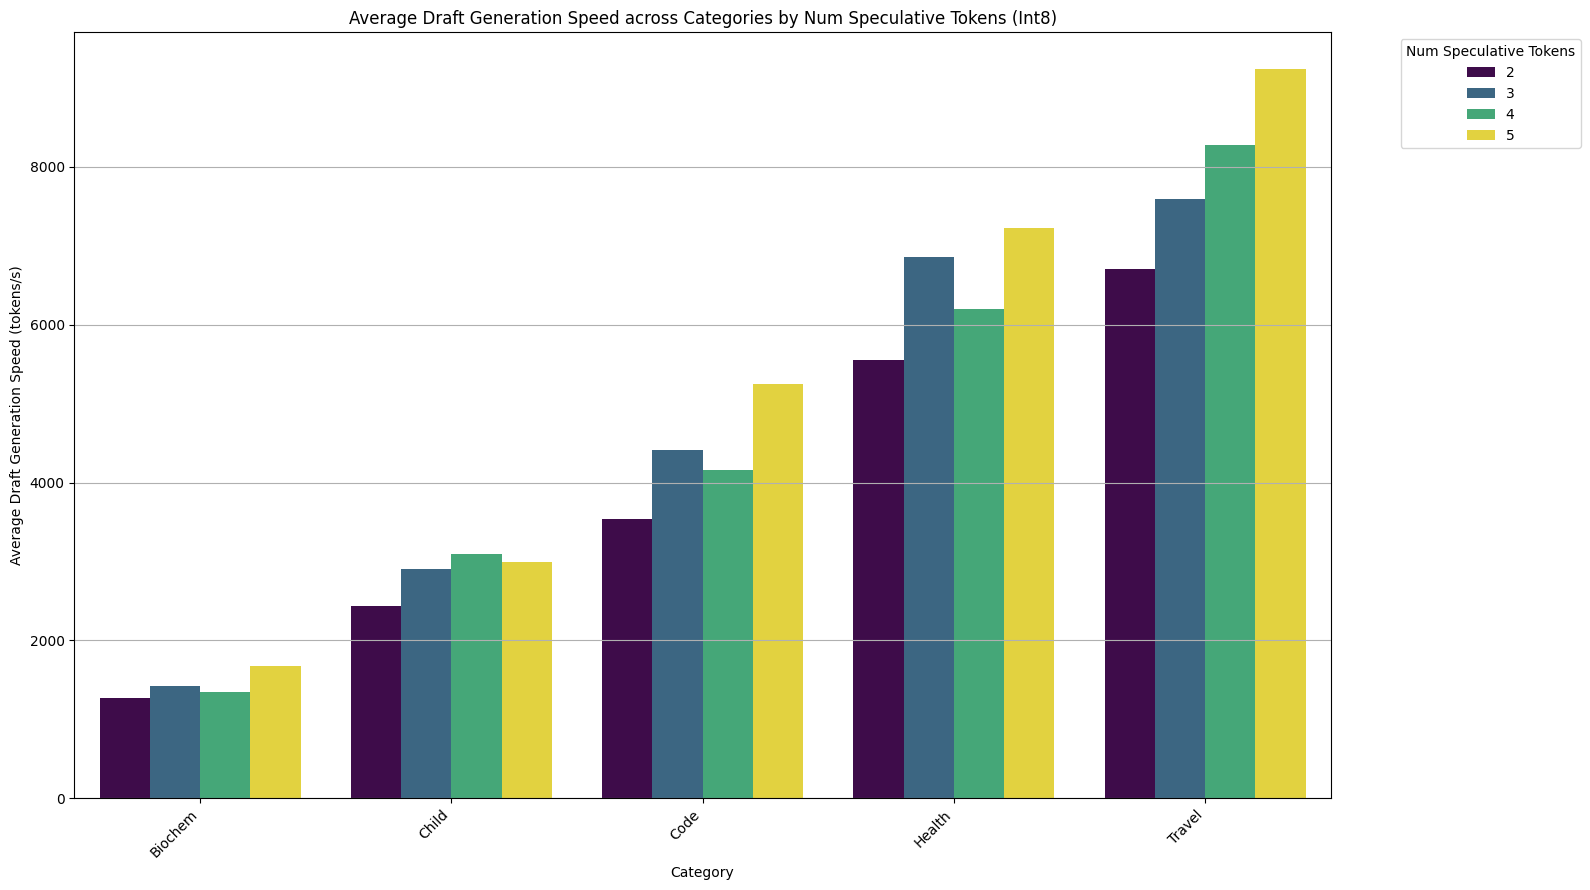

In [ ]:
analysis(model_filter = 'Int4', batch_size=0)

## Batch size 64

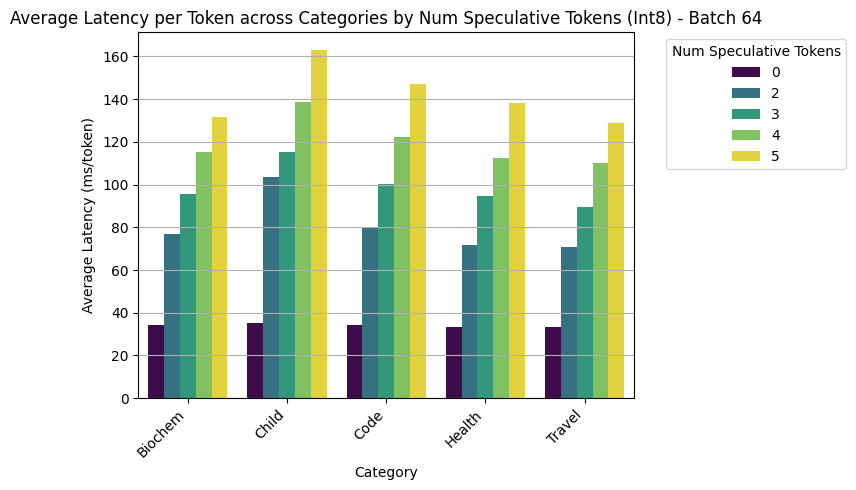

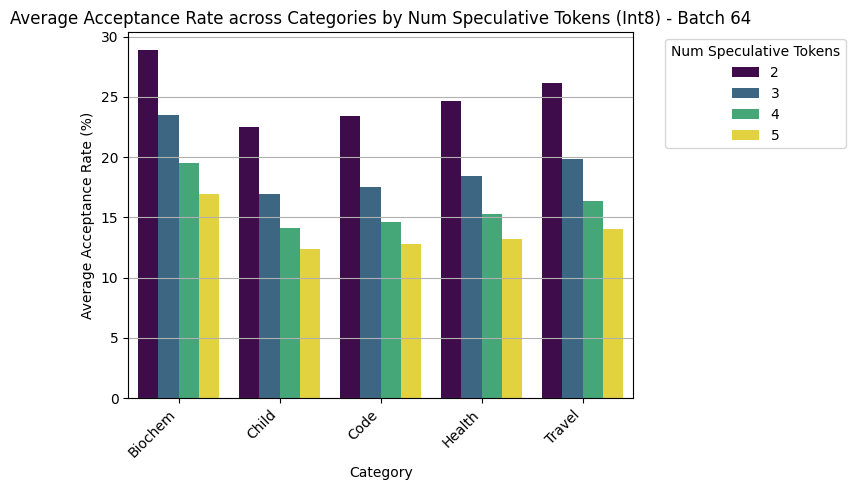

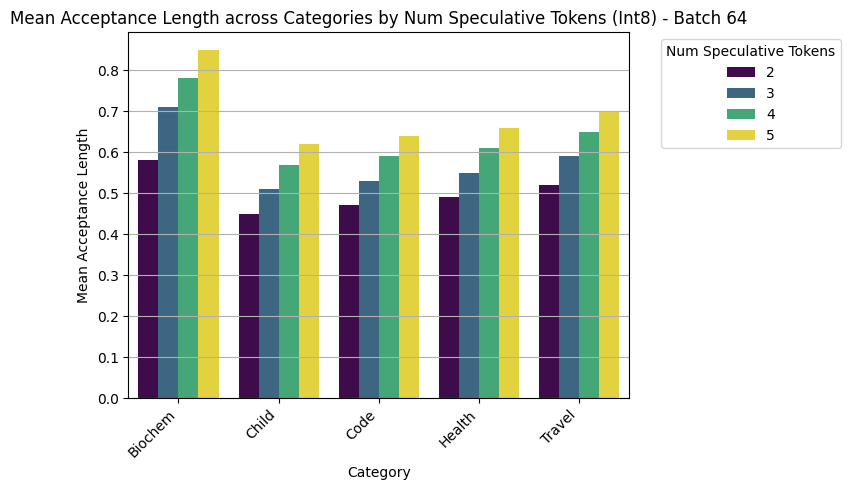

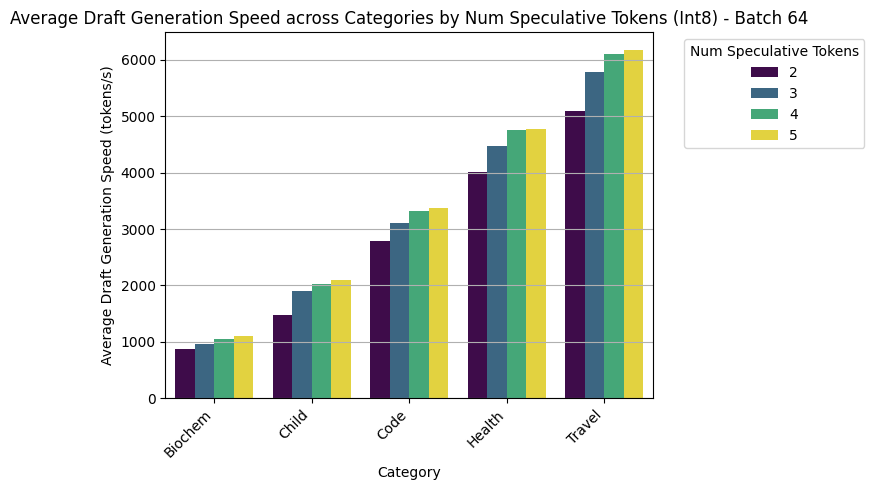

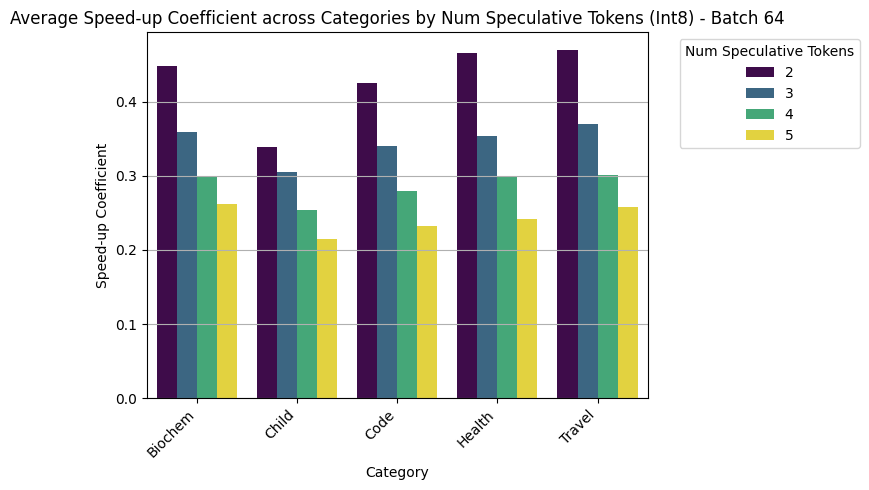

In [ ]:
analysis(model_filter='Int8', batch_size=64)

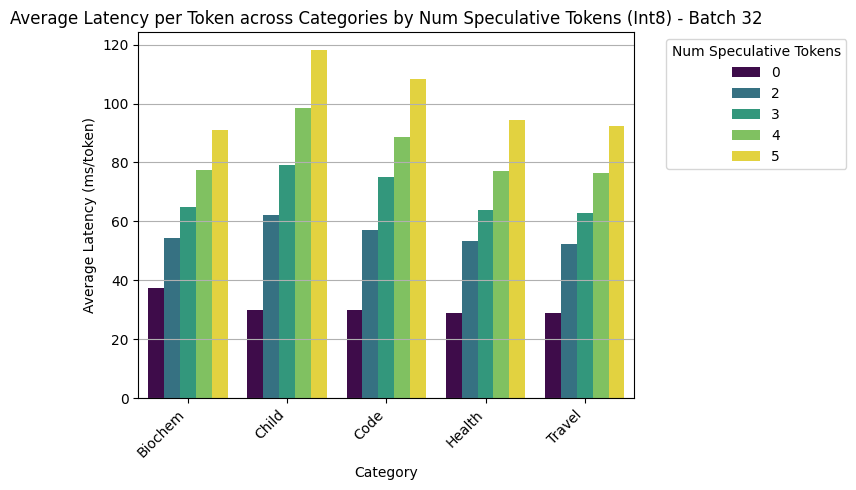

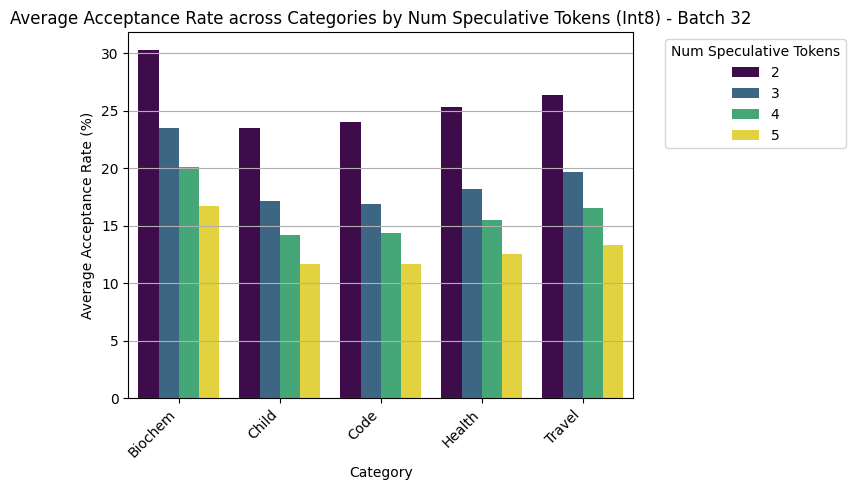

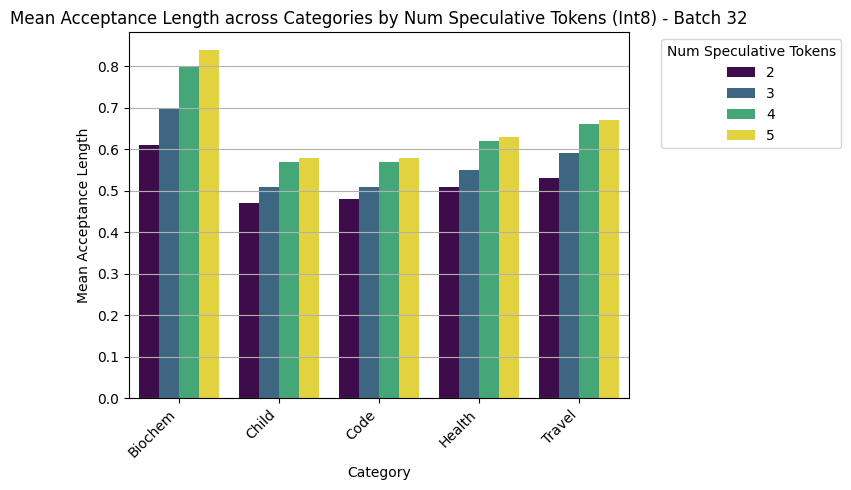

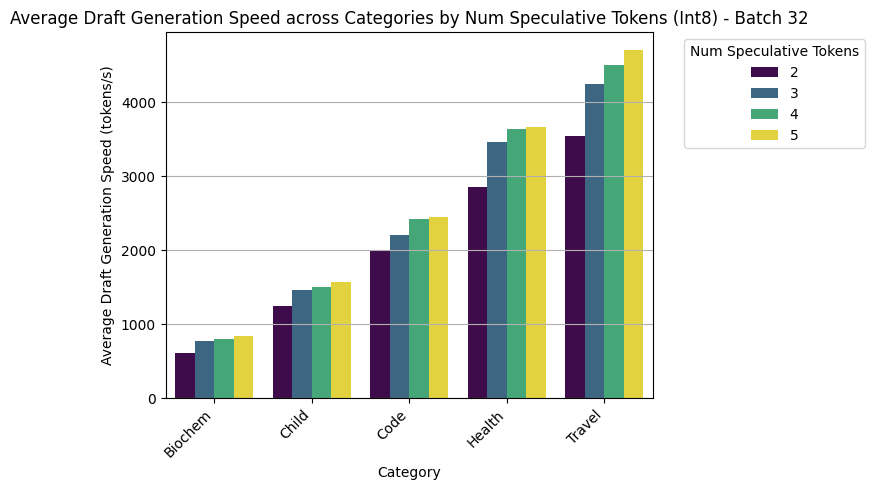

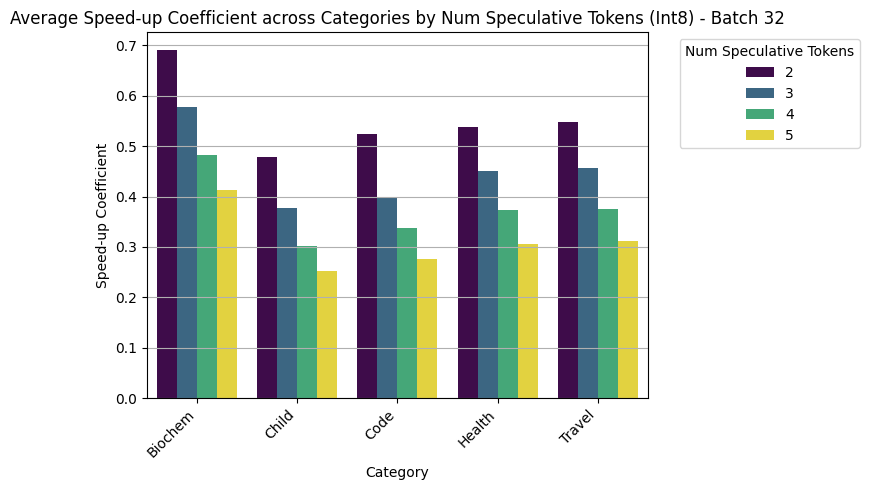

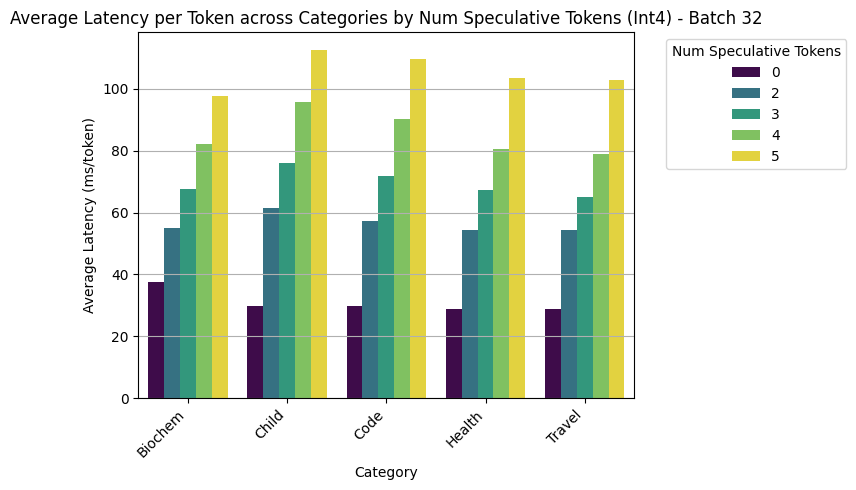

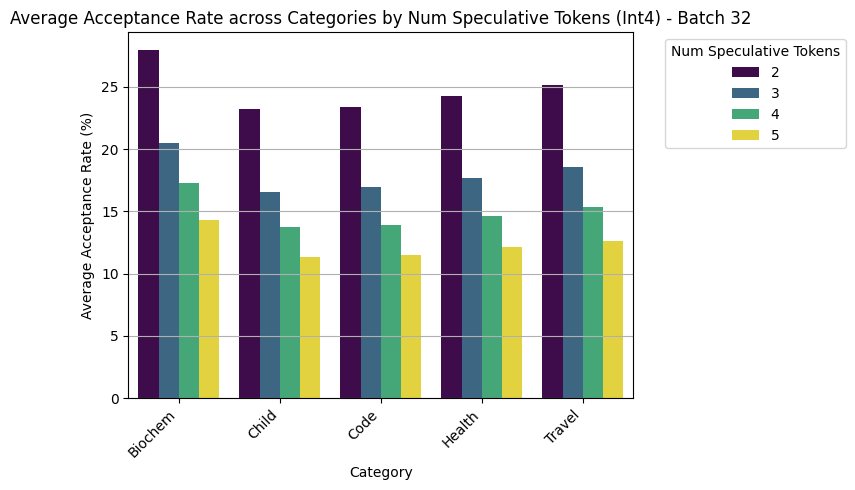

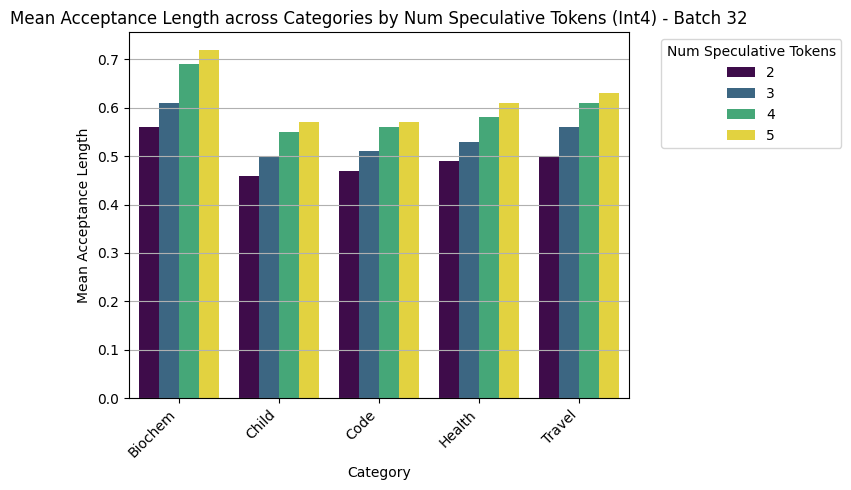

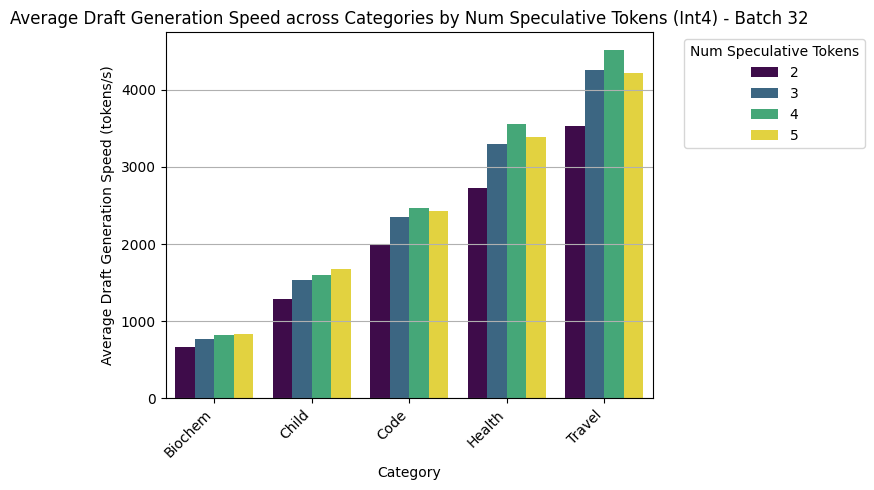

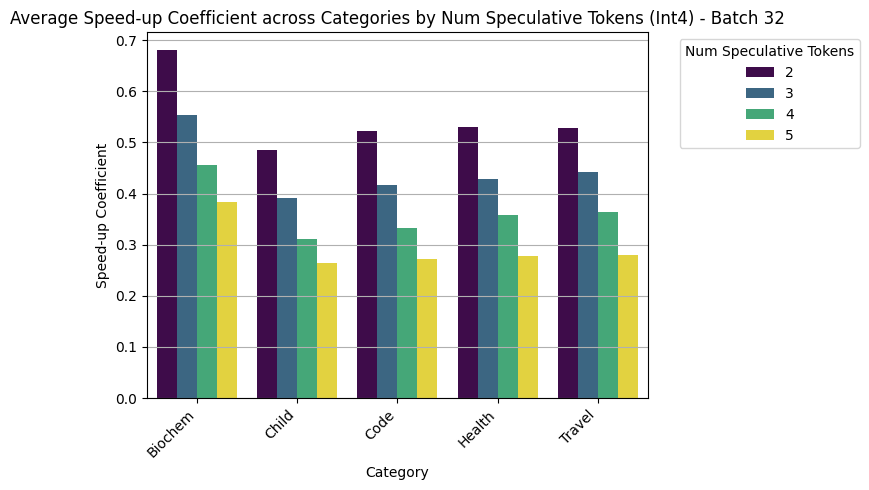

In [ ]:
MODEL_FILTER = 'Int8'
SPEC_TOKENS_COUNT = 3
BATCH_SIZES_TO_COMPARE = [32, 64]

comparison_df = df_global[
    (df_global['batch_size'].isin(BATCH_SIZES_TO_COMPARE)) &
    (df_global['Num Speculative Tokens'] == SPEC_TOKENS_COUNT) &
    (df_global['Draft Model'].str.contains(MODEL_FILTER))
].copy()

plot_df = comparison_df.groupby(
    ['Category', 'batch_size']
).agg({
    'Avg Acceptance Length': 'mean',
    'Draft Gen Speed (tokens/s)': 'mean',
    'Latency (ms/token)': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x='Category',
    y='Avg Acceptance Length',
    hue='batch_size',
    palette='viridis'
)
plt.title(f'Avg Acceptance Length for {MODEL_FILTER} Models (Speculative Tokens={SPEC_TOKENS_COUNT})')
plt.xlabel('Category')
plt.ylabel('Average Acceptance Length')
plt.grid(axis='y')
plt.legend(title='Batch Size', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x='Category',
    y='Draft Gen Speed (tokens/s)',
    hue='batch_size',
    palette='viridis'
)
plt.title(f'Avg Draft Generation Speed for {MODEL_FILTER} Models (Speculative Tokens={SPEC_TOKENS_COUNT})')
plt.xlabel('Category')
plt.ylabel('Average Draft Generation Speed (tokens/s)')
plt.grid(axis='y')
plt.legend(title='Batch Size', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x='Category',
    y='Latency (ms/token)',
    hue='batch_size',
    palette='viridis'
)
plt.title(f'Average Latency per Token for {MODEL_FILTER} Models (Speculative Tokens={SPEC_TOKENS_COUNT})')
plt.xlabel('Category')
plt.ylabel('Average Latency (ms/token)')
plt.grid(axis='y')
plt.legend(title='Batch Size', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

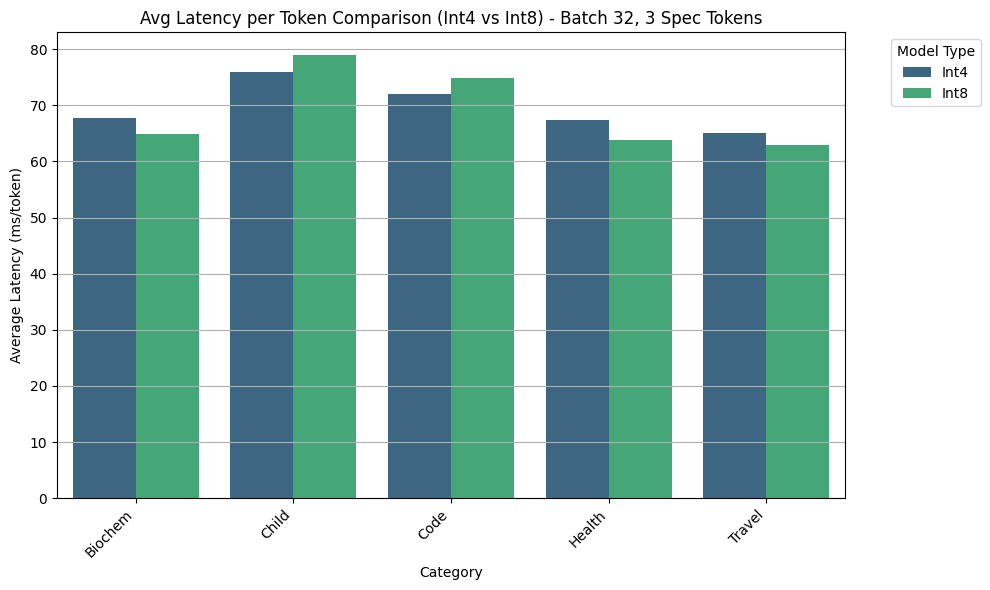

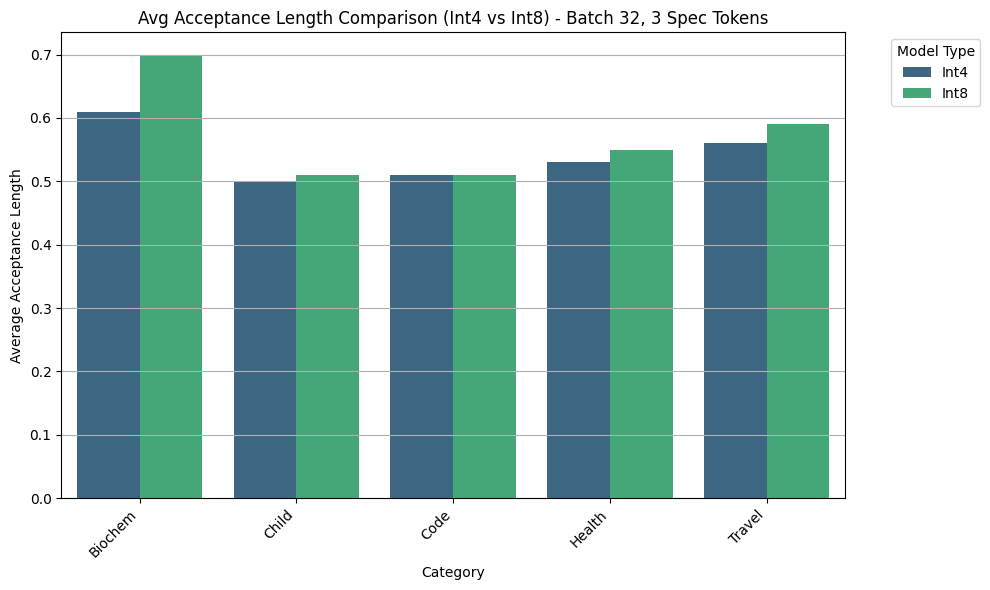

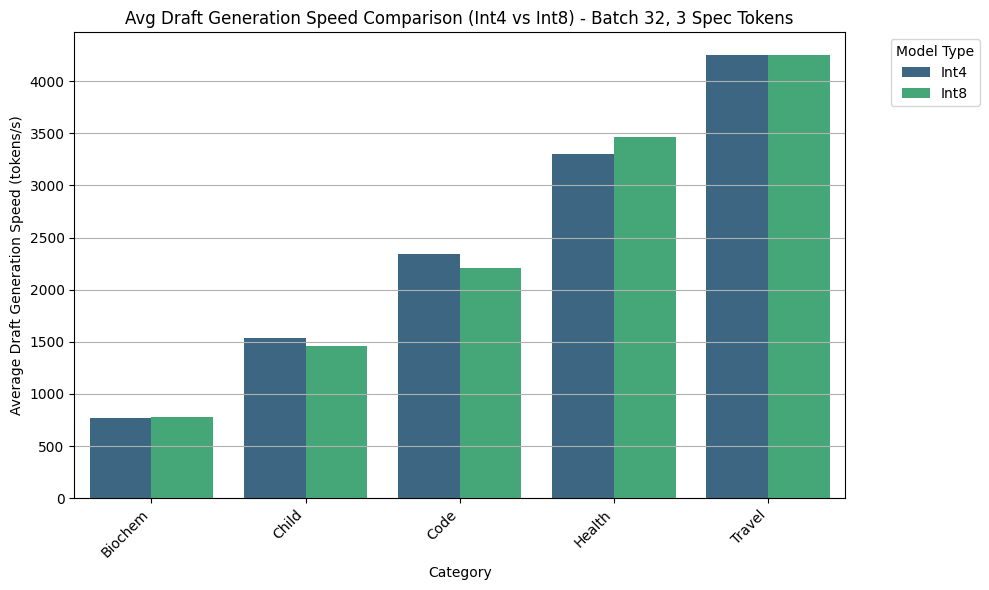

In [ ]:
SPEC_TOKENS_COUNT = 3
BATCH_SIZE = 32

comparison_df = df_global[
    (df_global['batch_size'] == BATCH_SIZE) &
    (df_global['Num Speculative Tokens'] == SPEC_TOKENS_COUNT)
].copy()

comparison_df['model_type'] = comparison_df['Draft Model'].apply(lambda x: 'Int4' if 'Int4' in x else ('Int8' if 'Int8' in x else 'Other'))
comparison_df = comparison_df[comparison_df['model_type'].isin(['Int4', 'Int8'])]


plot_df = comparison_df.groupby(
    ['Category', 'model_type']
).agg({
    'Latency (ms/token)': 'mean',
    'Avg Acceptance Length': 'mean',
    'Draft Gen Speed (tokens/s)': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x='Category',
    y='Latency (ms/token)',
    hue='model_type',
    palette='viridis'
)
plt.title(f'Avg Latency per Token Comparison (Int4 vs Int8) - Batch {BATCH_SIZE}, {SPEC_TOKENS_COUNT} Spec Tokens')
plt.xlabel('Category')
plt.ylabel('Average Latency (ms/token)')
plt.grid(axis='y')
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x='Category',
    y='Avg Acceptance Length',
    hue='model_type',
    palette='viridis'
)
plt.title(f'Avg Acceptance Length Comparison (Int4 vs Int8) - Batch {BATCH_SIZE}, {SPEC_TOKENS_COUNT} Spec Tokens')
plt.xlabel('Category')
plt.ylabel('Average Acceptance Length')
plt.grid(axis='y')
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x='Category',
    y='Draft Gen Speed (tokens/s)',
    hue='model_type',
    palette='viridis'
)
plt.title(f'Avg Draft Generation Speed Comparison (Int4 vs Int8) - Batch {BATCH_SIZE}, {SPEC_TOKENS_COUNT} Spec Tokens')
plt.xlabel('Category')
plt.ylabel('Average Draft Generation Speed (tokens/s)')
plt.grid(axis='y')
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()